### Week 7 — NLP Text Classification
- Build a model to classify text.

| Support Ticket | Category |
|-------------------------|-------------------|
| Cannot login | Login issue |
| Upload failed | Upload issue |
| Network timeout | Network issue |
| Permission denied | Permission issue |

  
  **Pipeline:**
1. Load The Data|set
2. Text preprocessing (clean the raw text)
3. TF-IDF vectorization (convert text → numbers)
4. Train/test split
5. Train a classifier
6. Evaluate performance
7. Predict on brand-new, unseen tickets

### 1.Import Libraries:

In [2]:
import pandas as pd
import numpy as np
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
STOPWORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

### 2.Loading The Dataset:

In [12]:
df = pd.read_csv('tickets.csv')
print(f"Dataset shape: {df.shape}")
print(f"Categories: {df['category'].nunique()}")

Dataset shape: (200, 2)
Categories: 8


In [4]:
df['category'].value_counts()

category
Upload issue         25
Login issue          25
Bug report           25
Permission issue     25
Payment issue        25
Network issue        25
Feature request      25
Performance issue    25
Name: count, dtype: int64

### 3.Text Preprocessing:

In [13]:
def clean_text(text: str) -> str:
    # Lowercase, strip non-letters, remove stopwords, lemmatize (as verbs)
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = text.lower()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w, pos='v') for w in tokens if w not in STOPWORDS]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text', 'category']].head(8)

,text,clean_text,category
0,Upload keeps getting stuck at 90 percent,upload keep get stick percent,Upload issue
1,Incorrect username or password error,incorrect username password error,Login issue
2,Upload fails with server error 500,upload fail server error,Upload issue
3,Settings not saving after change,settings save change,Bug report
4,Permission error when opening file,permission error open file,Permission issue
5,Unable to complete payment transaction,unable complete payment transaction,Payment issue
6,Payment method expired needs update,payment method expire need update,Payment issue
7,Form validation not working correctly,form validation work correctly,Bug report


##  4.TF-IDF Vectorization

Converts cleaned text into numeric feature vectors.

In [14]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
X = vectorizer.fit_transform(df['clean_text'])
y = df['category']

print('Feature matrix shape:',X.shape)
print('Vocabulary size:',len(vectorizer.vocabulary_))

Feature matrix shape: (200, 182)
Vocabulary size: 182


### 5.Train/Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42,stratify=y)
print('Train Data Size:',X_train.shape[0])
print('Test Data Size:',X_test.shape[0])

Train Data Size: 160
Test Data Size: 40


### 6.Train The Classifier Model

#### Logistic Regression:

In [16]:
lr_model = LogisticRegression()
lr_model.fit(X_train,y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.8
                   precision    recall  f1-score   support

       Bug report       0.67      0.40      0.50         5
  Feature request       1.00      0.80      0.89         5
      Login issue       1.00      0.80      0.89         5
    Network issue       0.80      0.80      0.80         5
    Payment issue       0.80      0.80      0.80         5
Performance issue       0.62      1.00      0.77         5
 Permission issue       0.83      1.00      0.91         5
     Upload issue       0.80      0.80      0.80         5

         accuracy                           0.80        40
        macro avg       0.82      0.80      0.79        40
     weighted avg       0.82      0.80      0.79        40



### Confusion Matrix:

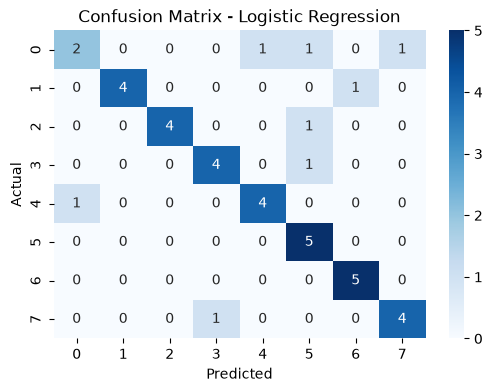

In [9]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 7.Predict Unseen Tickets:


In [10]:
def predict_category(text, model=lr_model, vec=vectorizer):
    cleaned = clean_text(text)
    vector = vec.transform([cleaned])
    prediction = model.predict(vector)[0]
    confidence = model.predict_proba(vector).max()
    return prediction, round(confidence, 3)

new_df = pd.read_csv('unseen_tickets.csv')
preds, confs = zip(*new_df['text'].apply(predict_category))

result_df = new_df.copy()
result_df['predicted_category'] = preds
result_df['confidence'] = confs
result_df

,text,predicted_category,confidence
0,Unable to sign into the portal,Login issue,0.183
1,Authentication failed while logging in,Login issue,0.435
2,Password reset link is not working,Login issue,0.418
3,Login verification code not received,Login issue,0.338
4,Getting stuck on sign in screen,Login issue,0.157
5,Cannot authenticate my account,Login issue,0.273
6,User account locked unexpectedly,Login issue,0.183
7,Login process keeps loading forever,Performance issue,0.245
8,Unable to access dashboard after login,Login issue,0.296
9,Receiving invalid credentials message,Login issue,0.210


In [11]:

def predict_cleaned(raw_text, model=lr_model, vec=vectorizer):
    cleaned = clean_text(raw_text)
    vector = vec.transform([cleaned])
    prediction = model.predict(vector)[0]
    confidence = model.predict_proba(vector).max()
    return prediction, round(confidence, 2)

new_reviews = [
    'unable to access my account after the recent update',
    'the app crashes every time I try to upload a photo',   
]

for review in new_reviews:
    pred, conf = predict_cleaned(review)

    print("=" * 60)
    print(f"📝 Review     : {review}")
    print(f"🎯 Predicted Sentiment  : {pred.capitalize()}")

📝 Review     : unable to access my account after the recent update
🎯 Predicted Sentiment  : Permission issue
📝 Review     : the app crashes every time I try to upload a photo
🎯 Predicted Sentiment  : Upload issue
